<a href="https://colab.research.google.com/github/Toepatella/calibrated-selective-prediction-clinical-shift/blob/main/phase0_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Split Conformal Prediction

### Step 0.1.1 -- Split conformal, by hand

Goal: see distribution-free marginal coverage appear empirically.

We train one small classifier on a toy multi-class problem (synthetic Gaussian blobs -- swap in the CIFAR-10 `Net` from the classifier tutorial if you want a heavier example; the conformal procedure is identical either way). Then, for many random calibration/test splits, we:

  1. Compute nonconformity scores s_i = 1 - f_{y_i}(x_i) on a calibration set (held out, not used for training).
  2. Set q_hat = the ceil((n+1)(1-alpha))-th smallest calibration score.
  3. Form prediction sets on test points: {y : 1 - f_y(x) <= q_hat}.
  4. Measure the fraction of test points whose true label landed in the set.

Assumption used: exchangeability of (calibration, test) points -- nothing else. No assumption on the model, the data distribution, or correctness of f.

Pitfall avoided: we use the ceil((n+1)(1-alpha))-th order statistic (not the plain n-quantile). The "+1" is what gives the finite-sample guarantee; dropping it undercovers, especially for small n.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

### 1. A toy classifier

Synthetic Gaussian blobs, K classes in D dimensions. Trains in a couple seconds, which matters since we re-run the cal/test split many times. (If you'd rather use the CIFAR-10 `Net` from the classifier tutorial, train it once, set `model = net`, `X_pool, y_pool = <test set tensors>`, and skip straight to Section 2 -- the conformal code only assumes model(x) returns logits.)

In [ ]:
K = 5            # number of classes
D = 8            # feature dimension
N_TRAIN = 2000
N_POOL = 4000    # pool we'll repeatedly re-split into calibration/test

def make_gaussian_blobs(n, K, D, class_sep=2.5):
    centers = np.random.randn(K, D) * class_sep
    y = np.random.randint(0, K, size=n)
    X = centers[y] + np.random.randn(n, D)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long), centers

X_train, y_train, centers = make_gaussian_blobs(N_TRAIN, K, D)

# pool drawn from the SAME centers so train/pool are exchangeable
y_pool = torch.randint(0, K, (N_POOL,))
X_pool = torch.tensor(centers[y_pool.numpy()], dtype=torch.float32) + torch.randn(N_POOL, D)

In [ ]:
class Net(nn.Module):
    def __init__(self, d_in, k_out):
        super().__init__()
        self.fc1 = nn.Linear(d_in, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, k_out)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
model = Net(D, K)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

for epoch in range(200):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

print(f"final train loss: {loss.item():.4f}")
with torch.no_grad():
    train_acc = (model(X_train).argmax(1) == y_train).float().mean().item()
print(f"train accuracy: {train_acc:.3f}")

final train loss: 0.0043
train accuracy: 0.998


### 2. Split conformal, by hand

Note this classifier is deliberately imperfect (overlapping Gaussian blobs) -- conformal coverage should hold regardless of how good or bad it is, which is the whole point: the guarantee comes from exchangeability of the calibration/test split, not from model accuracy.

In [ ]:
ALPHA = 0.10  # target miscoverage -> we want ~90% coverage

@torch.no_grad()
def softmax_probs(model, X):
    return F.softmax(model(X), dim=1)

def conformal_quantile(scores, alpha):
    """q_hat = ceil((n+1)(1-alpha))-th smallest score, clipped to <= 1."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(k, n)  # if k > n, q_hat is effectively infinite (use max score)
    return np.sort(scores)[k - 1]

In [ ]:
def one_split_coverage(model, X_pool, y_pool, n_cal, alpha):
    n_pool = X_pool.shape[0]
    perm = torch.randperm(n_pool)
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

    X_cal, y_cal = X_pool[cal_idx], y_pool[cal_idx]
    X_test, y_test = X_pool[test_idx], y_pool[test_idx]

    probs_cal = softmax_probs(model, X_cal)
    s_cal = (1 - probs_cal[torch.arange(len(y_cal)), y_cal]).numpy()
    q_hat = conformal_quantile(s_cal, alpha)

    probs_test = softmax_probs(model, X_test)
    nonconf_test = 1 - probs_test  # shape (n_test, K): nonconformity per candidate label
    pred_sets = nonconf_test <= q_hat  # bool mask, True where label y is included

    covered = pred_sets[torch.arange(len(y_test)), y_test]
    avg_set_size = pred_sets.float().sum(dim=1).mean().item()
    return covered.float().mean().item(), avg_set_size, q_hat

In [ ]:
N_SPLITS = 500
N_CAL = 300

coverages = []
set_sizes = []
for _ in range(N_SPLITS):
    cov, size, _ = one_split_coverage(model, X_pool, y_pool, N_CAL, ALPHA)
    coverages.append(cov)
    set_sizes.append(size)

coverages = np.array(coverages)
print(f"target coverage: {1 - ALPHA:.3f}")
print(f"mean realized coverage over {N_SPLITS} splits: {coverages.mean():.4f}")
print(f"std of realized coverage: {coverages.std():.4f}")
print(f"mean prediction-set size: {np.mean(set_sizes):.2f} (of {K} classes)")

target coverage: 0.900
mean realized coverage over 500 splits: 0.9003
std of realized coverage: 0.0190
mean prediction-set size: 0.90 (of 5 classes)


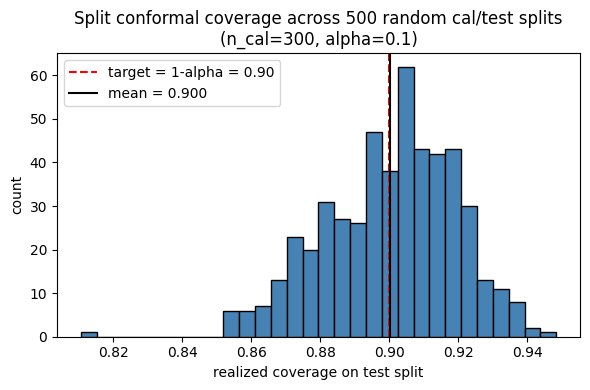

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(coverages, bins=30, color="steelblue", edgecolor="black")
plt.axvline(1 - ALPHA, color="red", linestyle="--", label=f"target = 1-alpha = {1-ALPHA:.2f}")
plt.axvline(coverages.mean(), color="black", linestyle="-", label=f"mean = {coverages.mean():.3f}")
plt.xlabel("realized coverage on test split")
plt.ylabel("count")
plt.title(f"Split conformal coverage across {N_SPLITS} random cal/test splits\n(n_cal={N_CAL}, alpha={ALPHA})")
plt.legend()
plt.tight_layout()
plt.show()

### 3. The pitfall, demonstrated

Use the plain n-th smallest score (no "+1") instead of ceil((n+1)(1-alpha)), and watch mean coverage fall measurably below 1-alpha -- most noticeably at small n_cal.

In [ ]:
def buggy_quantile(scores, alpha):
    """WRONG: uses ceil(n * (1 - alpha)) instead of ceil((n+1) * (1 - alpha)). Undercovers."""
    n = len(scores)
    k = int(np.ceil(n * (1 - alpha)))
    k = min(max(k, 1), n)
    return np.sort(scores)[k - 1]

In [ ]:
def one_split_coverage_buggy(model, X_pool, y_pool, n_cal, alpha):
    n_pool = X_pool.shape[0]
    perm = torch.randperm(n_pool)
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]
    X_cal, y_cal = X_pool[cal_idx], y_pool[cal_idx]
    X_test, y_test = X_pool[test_idx], y_pool[test_idx]

    probs_cal = softmax_probs(model, X_cal)
    s_cal = (1 - probs_cal[torch.arange(len(y_cal)), y_cal]).numpy()
    q_hat = buggy_quantile(s_cal, alpha)

    probs_test = softmax_probs(model, X_test)
    pred_sets = (1 - probs_test) <= q_hat
    covered = pred_sets[torch.arange(len(y_test)), y_test]
    return covered.float().mean().item()

In [ ]:
N_CAL_SMALL = 30  # small n makes the +1 effect obvious
buggy_cov = [one_split_coverage_buggy(model, X_pool, y_pool, N_CAL_SMALL, ALPHA) for _ in range(N_SPLITS)]
correct_cov = [one_split_coverage(model, X_pool, y_pool, N_CAL_SMALL, ALPHA)[0] for _ in range(N_SPLITS)]

print(f"n_cal = {N_CAL_SMALL}, target = {1 - ALPHA:.3f}")
print(f"correct (+1) mean coverage:   {np.mean(correct_cov):.4f}")
print(f"buggy (no +1) mean coverage:  {np.mean(buggy_cov):.4f}")

n_cal = 30, target = 0.900
correct (+1) mean coverage:   0.9025
buggy (no +1) mean coverage:  0.8714


### Done-when check

- Mean realized coverage above (Section 2) should sit close to 1-alpha -- run the script a few times / increase N_SPLITS if it looks off.
- The only assumption used anywhere in one_split_coverage is that calibration and test points are exchangeable draws from the same pool -- nothing about the model's accuracy, the data's distribution shape, or the number of classes was assumed.
- Quantile to recall from memory: q_hat = the ceil((n+1)(1-alpha))-th smallest calibration nonconformity score (Section 3 shows what breaks without the "+1").

## Conformal Risk Control (CRC)

### Step 0.1.2 -- Conformal risk control

Goal: control an *expected loss*, not just miscoverage.

Split conformal (Step 0.1.1) controls one specific risk: the probability the true label falls outside the set. CRC (Angelopoulos, Bates, Fisch, Lei, Schuster, *Conformal Risk Control*, ICLR 2024 -- https://github.com/aangelopoulos/conformal-risk) generalizes this to **any bounded, monotone loss**.

Setup. Pick a threshold parameter `lambda` that grows the prediction set as it increases, and a per-example loss `L_i(lambda)` that is

  - **monotone non-increasing in lambda** (bigger set -> smaller loss), and
  - **bounded**: `0 <= L_i(lambda) <= B` for some finite `B`.

Given calibration losses, CRC picks

    lambda_hat = inf { lambda : (n/(n+1)) * Rhat_n(lambda) + B/(n+1) <= alpha }

where `Rhat_n(lambda) = (1/n) sum_i L_i(lambda)` is the empirical calibration risk. The theorem guarantees

    E[ L_test(lambda_hat) ] <= alpha.

When `L_i(lambda) = 1{ y_i not in C_lambda(x_i) }` (the miscoverage indicator, `B = 1`), CRC reduces exactly to split conformal -- so Step 0.1.1 is the special case. Below we use a genuinely different loss to show the generality.

In [ ]:
# Faithful reproduction of core/get_lhat.py from aangelopoulos/conformal-risk.
# calib_loss_table: (n_cal, n_lambda). Columns MUST run from SMALL loss to LARGE
#   loss -- i.e. lambdas arranged so the set shrinks (loss grows) as the column
#   index increases. lambdas: matching 1-D array. B: the loss upper bound.
# Returns the tightest lambda_hat whose inflated empirical risk
#   (n/(n+1)) * Rhat(lambda) + B/(n+1) is still <= alpha.
def get_lhat(calib_loss_table, lambdas, alpha, B=1):
    n = calib_loss_table.shape[0]
    rhat = calib_loss_table.mean(axis=0)
    lhat_idx = max(np.argmax(((n / (n + 1)) * rhat + B / (n + 1)) >= alpha) - 1, 0)
    return lambdas[lhat_idx]


# Thin alias matching the task's naming.
def crc(calib_loss_table, lambdas, alpha, B=1.0):
    return get_lhat(calib_loss_table, lambdas, alpha, B)

### A multilabel toy (so the loss isn't just 0/1 coverage)

In the single-label problem of Step 0.1.1 the only natural per-example loss is the miscoverage indicator -- which just gives back conformal prediction. To exercise CRC on something different we switch to **multilabel** classification: each `x` has a *set* of true labels, and we control the **false-negative rate (FNR)** -- the fraction of an example's true labels we miss.

  - Prediction set at threshold lambda:  `C_lambda(x) = { k : f_k(x) >= 1 - lambda }`.
    lambda = 0 -> threshold 1 -> ~empty set; lambda = 1 -> threshold 0 -> all labels.
  - Loss:  `L_i(lambda) = 1 - |true labels kept| / |true labels|`  (FNR for example i).

This loss is **non-increasing in lambda** (a bigger set can only recover more true labels) and **bounded by B = 1**, so the vanilla CRC bound applies. We guarantee at least one positive label per example so the FNR denominator is never zero.

In [ ]:
# --- synthetic multilabel data: shared generative weights so train/pool are exchangeable ---
L = 10        # number of candidate labels
D2 = 20       # feature dim
N_ML_TRAIN = 3000
N_ML_POOL = 5000

torch.manual_seed(1)

def make_multilabel(n, W, b):
    L, D2 = W.shape
    X = torch.randn(n, D2)
    probs = torch.sigmoid(X @ W.T + b)
    Y = (torch.rand(n, L) < probs).float()
    empty = Y.sum(1) == 0
    if empty.any():
        Y[empty, probs[empty].argmax(1)] = 1.0   # guarantee >=1 positive (FNR well-defined)
    return X, Y

W_true = torch.randn(L, D2)
b_true = torch.randn(L) - 1.0                     # bias toward sparser label sets
X_ml_train, Y_ml_train = make_multilabel(N_ML_TRAIN, W_true, b_true)
X_ml_pool,  Y_ml_pool  = make_multilabel(N_ML_POOL,  W_true, b_true)

# --- train a small multilabel classifier (independent sigmoids via BCE) ---
ml_model = nn.Sequential(nn.Linear(D2, 64), nn.ReLU(), nn.Linear(64, L))
opt = optim.Adam(ml_model.parameters(), lr=1e-2)
bce = nn.BCEWithLogitsLoss()
for epoch in range(300):
    opt.zero_grad()
    bce_loss = bce(ml_model(X_ml_train), Y_ml_train)
    bce_loss.backward()
    opt.step()
print(f"avg true labels/example: {Y_ml_train.sum(1).mean():.2f}")
print(f"final BCE: {bce_loss.item():.4f}")


@torch.no_grad()
def label_probs(model, X):
    return torch.sigmoid(model(X))


# FNR per (example, lambda) -> (n, n_lambda) numpy array.
def fnr_loss_table(probs, Y, lambdas):
    thresh = 1 - lambdas                                              # (G,)
    included = probs[:, :, None] >= torch.tensor(thresh, dtype=probs.dtype)[None, None, :]
    tp = (Y[:, :, None].bool() & included).sum(1).float()            # true labels kept: (n, G)
    npos = Y.sum(1, keepdim=True)                                     # (n, 1), >= 1
    return (1 - tp / npos).numpy()


# lambdas DESCENDING: 1.0 (biggest set, smallest loss) -> 0.0 (smallest set, largest loss),
# so the loss-table columns run small-loss -> large-loss as get_lhat expects.
G = 100
lambdas = np.linspace(1.0, 0.0, G)
ALPHA_CRC = 0.10                 # control expected FNR at 10% (keep >= 90% of true labels on avg)
B = 1.0

# sanity: loss really is monotone in lambda and spans [0, ~1]
_col = fnr_loss_table(label_probs(ml_model, X_ml_pool), Y_ml_pool, lambdas).mean(0)
print("monotone non-increasing in lambda:", bool(np.all(np.diff(_col) >= -1e-9)))
print(f"mean loss at lambda=1: {_col[0]:.3f}   at lambda=0: {_col[-1]:.3f}")

### Calibrate on one split, test on the rest

`get_lhat` reads the calibration loss table, inflates the empirical risk by the `(n, B)` finite-sample correction, and returns the tightest `lambda_hat` that keeps it `<= alpha`. We then build sets on the held-out test points and measure the realized FNR.

In [ ]:
def one_split_crc(model, X_pool, Y_pool, n_cal, lambdas, alpha, B):
    perm = torch.randperm(X_pool.shape[0])
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

    cal_tbl = fnr_loss_table(label_probs(model, X_pool[cal_idx]), Y_pool[cal_idx], lambdas)
    lhat = crc(cal_tbl, lambdas, alpha, B)                 # <-- CRC threshold

    probs_test = label_probs(model, X_pool[test_idx])
    incl = probs_test >= (1 - lhat)
    tp = (Y_pool[test_idx].bool() & incl).sum(1).float()
    npos = Y_pool[test_idx].sum(1)
    test_fnr = (1 - tp / npos).mean().item()
    avg_set = incl.float().sum(1).mean().item()
    return test_fnr, lhat, avg_set

fnr, lhat, sz = one_split_crc(ml_model, X_ml_pool, Y_ml_pool, 1000, lambdas, ALPHA_CRC, B)
print(f"lambda_hat = {lhat:.3f}")
print(f"realized test FNR = {fnr:.4f}   (target alpha = {ALPHA_CRC})")
print(f"avg prediction-set size = {sz:.2f} of {L} labels")

### Does E[loss] land at or below alpha?

CRC controls the loss *in expectation over the calibration draw* -- `lambda_hat` is itself random (it depends on which points landed in calibration). So the right check is the **mean realized test risk across many random cal/test splits**, not any single split.

In [ ]:
N_SPLITS_CRC = 300
N_CAL_CRC = 1000

risks = np.array([
    one_split_crc(ml_model, X_ml_pool, Y_ml_pool, N_CAL_CRC, lambdas, ALPHA_CRC, B)[0]
    for _ in range(N_SPLITS_CRC)
])

print(f"target alpha = {ALPHA_CRC}")
print(f"mean realized test FNR over {N_SPLITS_CRC} splits: {risks.mean():.4f}  (should be <= {ALPHA_CRC})")
print(f"std: {risks.std():.4f}")
print(f"fraction of individual splits above alpha: {(risks > ALPHA_CRC).mean():.2f}  "
      f"(per-draw can exceed alpha; only the MEAN is guaranteed)")

plt.figure(figsize=(6, 4))
plt.hist(risks, bins=30, color="seagreen", edgecolor="black")
plt.axvline(ALPHA_CRC, color="red", linestyle="--", label=f"alpha = {ALPHA_CRC}")
plt.axvline(risks.mean(), color="black", linestyle="-", label=f"mean = {risks.mean():.3f}")
plt.xlabel("realized test FNR (expected loss)")
plt.ylabel("count")
plt.title(f"CRC controls E[loss] across {N_SPLITS_CRC} cal/test splits\n(n_cal={N_CAL_CRC}, alpha={ALPHA_CRC}, B={B})")
plt.legend()
plt.tight_layout()
plt.show()

### Done-when check

- **What CRC controls.** `E[ L_test(lambda_hat) ] <= alpha`, where the expectation is taken over **both** the test point **and the calibration draw** (because `lambda_hat` is a random function of the calibration set). The histogram above makes this concrete: the *mean* sits at/just below alpha, while a sizable fraction of individual splits land above it. That is allowed -- CRC is a statement about the average over calibration draws, not a per-calibration (conditional) promise. Same flavor as conformal's *marginal* coverage in Step 0.1.1.
- **Why that differs from a per-model guarantee.** A per-model / per-calibration guarantee would require `E[L_test(lambda_hat) | calibration set] <= alpha` for *every* calibration set. CRC does not give that; it gives control only after also averaging over the calibration randomness. Fix one unlucky calibration draw and the conditional risk can exceed alpha.
- **Pitfall.** The vanilla bound needs the loss to be (i) **monotone** in lambda and (ii) **bounded** by a known `B` (we used FNR: monotone non-increasing, `B = 1`). Lose monotonicity (so the empirical risk isn't a clean monotone function of lambda) or boundedness (so the `B/(n+1)` correction is wrong) and the guarantee no longer holds.
- **Recall the threshold from memory:** `lambda_hat = inf { lambda : (n/(n+1)) * Rhat_n(lambda) + B/(n+1) <= alpha }`; with the 0/1 miscoverage loss and `B = 1` this collapses back to the Step 0.1.1 conformal quantile.

## Selective Prediction

### Step 0.1.3 -- Selective prediction + why naive filtering breaks

Goal: build the abstain gate and feel the selection bias.

A *selective* predictor is allowed to say "I don't know." It pairs the classifier `f` with a **gate**

    g(x) = 1[ u(x) <= tau ]      # 1 = predict, 0 = abstain

where `u(x)` is an uncertainty score -- here either **softmax-response** `u(x) = 1 - max_y f_y(x)` (small = confident) or **entropy** `u(x) = -sum_y f_y(x) log f_y(x)`. Lower `tau` -> abstain more -> act only on the points the model is surest about.

We will (a) build the gate, (b) draw the **risk-coverage curve** and compute **AURC**, then (c) spring the trap: a conformal predictor calibrated on *all* data does **not** keep its `1 - alpha` guarantee once you look only at the *accepted* points.

> **Pitfall flagged up front (two different axes).** "Coverage" is overloaded here:
> - *selective coverage* = the fraction of points we accept (don't abstain on);
> - *conformal coverage* = the fraction of accepted points whose true label is in the prediction set.
> A model can have a beautiful risk-coverage curve and still have conformal coverage on the accepted region nowhere near `1 - alpha`. We report **both** and never plot them on the same axis.

### A harder toy (so confidence actually varies)

The Step 0.1.1 blobs are ~99.8% accurate -- there's nothing to abstain on. We reuse `make_gaussian_blobs` with a much smaller `class_sep` so the classes overlap, the model makes real mistakes, and `u(x)` carries information about which points are risky.

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

SEP = 0.8                          # overlapping blobs -> ~83% accuracy, real uncertainty
Xs_train, ys_train, centers_s = make_gaussian_blobs(4000, K, D, class_sep=SEP)
ys_pool = torch.randint(0, K, (8000,))
Xs_pool = torch.tensor(centers_s[ys_pool.numpy()], dtype=torch.float32) + torch.randn(8000, D)

sel_model = Net(D, K)
opt = optim.SGD(sel_model.parameters(), lr=0.05, momentum=0.9)
crit = nn.CrossEntropyLoss()
for epoch in range(200):
    opt.zero_grad()
    loss = crit(sel_model(Xs_train), ys_train)
    loss.backward()
    opt.step()

probs_sel = softmax_probs(sel_model, Xs_pool)
preds = probs_sel.argmax(1)
correct = (preds == ys_pool).numpy().astype(float)
u_sr = (1 - probs_sel.max(1).values).numpy()                         # softmax-response uncertainty
u_ent = (-(probs_sel * torch.log(probs_sel + 1e-12)).sum(1)).numpy()  # entropy uncertainty
print(f"pool accuracy: {correct.mean():.3f}  (so full-coverage selective risk ~= {1-correct.mean():.3f})")

### (a)+(b) The abstain gate and the risk-coverage curve

Sweep the gate from "abstain on everything" to "accept everything." Accepting the most-confident points first traces the **risk-coverage curve**: x = selective coverage (fraction accepted), y = **selective risk** (top-1 error rate *among accepted points*). A good uncertainty score pushes the curve down-and-right: low risk while still accepting a lot.

**AURC** (area under the risk-coverage curve) summarizes it in one number -- lower is better. We compute it for both softmax-response and entropy.

In [ ]:
def risk_coverage(u, correct):
    order = np.argsort(u)                               # accept lowest-uncertainty first
    cs = correct[order]
    k = np.arange(1, len(u) + 1)
    coverage = k / len(u)                               # fraction accepted
    sel_risk = 1 - np.cumsum(cs) / k                    # error rate on the accepted prefix
    return coverage, sel_risk

def aurc(u, correct):
    return risk_coverage(u, correct)[1].mean()          # empirical area under the curve

cov_sr, risk_sr = risk_coverage(u_sr, correct)
cov_ent, risk_ent = risk_coverage(u_ent, correct)
print(f"AURC (softmax-response): {aurc(u_sr, correct):.4f}")
print(f"AURC (entropy):          {aurc(u_ent, correct):.4f}")

# the gate at one operating point: accept the 50% most confident
tau = float(np.quantile(u_sr, 0.5))
g = u_sr <= tau                                         # g(x) = 1[u(x) <= tau]
print(f"\ngate at tau={tau:.3f}: selective coverage={g.mean():.3f} (fraction accepted), "
      f"selective risk={1 - correct[g].mean():.3f} (error on accepted)")

plt.figure(figsize=(6, 4))
plt.plot(cov_sr, risk_sr, label=f"softmax-response (AURC={aurc(u_sr, correct):.3f})")
plt.plot(cov_ent, risk_ent, label=f"entropy (AURC={aurc(u_ent, correct):.3f})", linestyle="--")
plt.xlabel("selective coverage (fraction accepted)")
plt.ylabel("selective risk (error on accepted)")
plt.title("Risk-coverage curve")
plt.legend()
plt.tight_layout()
plt.show()

### (c) The trap: calibrate conformal on all data, evaluate on accepted only

Now combine the gate with the split-conformal predictor from Step 0.1.1. We calibrate `q_hat` on **all** calibration points (so it's valid *marginally*), build sets `C(x) = {y : 1 - f_y(x) <= q_hat}` on test, and then ask: among the points the gate **accepts**, what is the conformal coverage?

Across many splits we record coverage on the full test set, on the accepted subset, and on the rejected subset.

In [ ]:
ALPHA = 0.10
torch.manual_seed(1)
np.random.seed(1)
N_SPLITS, N_CAL = 150, 2000
accept_fracs = np.linspace(0.9, 0.2, 8)   # gate tau = this quantile of pool uncertainty

results = {}   # accept_frac -> mean coverages (full / accepted-q_all / rejected / accepted-q_accepted)
for af in accept_fracs:
    tau_af = float(np.quantile(u_sr, af))
    full, acc_all, rej, acc_fix = [], [], [], []
    for _ in range(N_SPLITS):
        perm = torch.randperm(Xs_pool.shape[0])
        cal, test = perm[:N_CAL], perm[N_CAL:]
        p_cal = softmax_probs(sel_model, Xs_pool[cal]); yc = ys_pool[cal]
        p_test = softmax_probs(sel_model, Xs_pool[test]); yt = ys_pool[test]
        s_cal = (1 - p_cal[torch.arange(len(yc)), yc]).numpy()
        s_test = (1 - p_test[torch.arange(len(yt)), yt]).numpy()
        u_cal = (1 - p_cal.max(1).values).numpy()
        u_test = (1 - p_test.max(1).values).numpy()

        q_all = conformal_quantile(s_cal, ALPHA)         # calibrate on ALL cal points
        covered = s_test <= q_all
        amask = u_test <= tau_af                         # gate on test
        full.append(covered.mean())
        acc_all.append(covered[amask].mean())
        rej.append(covered[~amask].mean())

        q_acc = conformal_quantile(s_cal[u_cal <= tau_af], ALPHA)  # FIX (used in next section)
        acc_fix.append((s_test[amask] <= q_acc).mean())
    results[af] = dict(full=np.mean(full), acc_all=np.mean(acc_all),
                       rej=np.mean(rej), acc_fix=np.mean(acc_fix))

print(f"target conformal coverage = {1 - ALPHA}\n")
print(f"{'accept%':>8}{'full':>9}{'accepted':>11}{'rejected':>11}")
for af in (0.7, 0.5, 0.3):
    r = results[min(accept_fracs, key=lambda x: abs(x - af))]
    print(f"{af*100:7.0f}%{r['full']:9.3f}{r['acc_all']:11.3f}{r['rej']:11.3f}")

afs = sorted(results)
plt.figure(figsize=(6, 4))
plt.plot(afs, [results[a]['acc_all'] for a in afs], "o-", label="coverage on ACCEPTED (q_all)")
plt.plot(afs, [results[a]['rej'] for a in afs], "s-", label="coverage on rejected (q_all)")
plt.plot(afs, [results[a]['full'] for a in afs], "^-", label="coverage on full test")
plt.axhline(1 - ALPHA, color="red", linestyle="--", label=f"target 1-alpha = {1-ALPHA}")
plt.xlabel("gate accept fraction (tighter gate ->)")
plt.ylabel("conformal coverage")
plt.title("Marginal guarantee holds on full test, NOT on selected subsets")
plt.legend()
plt.tight_layout()
plt.show()

### The fix: calibrate on the accepted region

The gate depends only on `x` (through `u(x)`). So *conditional on acceptance*, the accepted calibration points and accepted test points are i.i.d. from the **same** conditional distribution -- they are exchangeable with each other, even though neither is exchangeable with the full, unfiltered calibration set. Re-deriving `q_hat` from the calibration points **that pass the same gate** therefore restores `1 - alpha` coverage on the accepted region. (This is just split conformal applied to the accepted subpopulation -- a Mondrian / group-conditional calibration.)

We already computed this as `q_accepted` in the loop above; here we compare it against the broken `q_all`.

In [ ]:
print(f"target conformal coverage = {1 - ALPHA}\n")
print(f"{'accept%':>8}{'accepted (q_all)':>20}{'accepted (q_accepted)':>24}")
for af in (0.7, 0.5, 0.3):
    r = results[min(accept_fracs, key=lambda x: abs(x - af))]
    print(f"{af*100:7.0f}%{r['acc_all']:20.3f}{r['acc_fix']:24.3f}")

afs = sorted(results)
plt.figure(figsize=(6, 4))
plt.plot(afs, [results[a]['acc_all'] for a in afs], "o-", label="accepted, q calibrated on ALL (broken)")
plt.plot(afs, [results[a]['acc_fix'] for a in afs], "D-", label="accepted, q calibrated on ACCEPTED (fixed)")
plt.axhline(1 - ALPHA, color="red", linestyle="--", label=f"target 1-alpha = {1-ALPHA}")
plt.xlabel("gate accept fraction (tighter gate ->)")
plt.ylabel("conformal coverage on accepted")
plt.title("Calibrating on the accepted region restores the guarantee")
plt.legend()
plt.tight_layout()
plt.show()

### Done-when check

- **One-sentence why.** Filtering by `u(x)` makes the accepted test points i.i.d. draws from the *conditional* distribution `P(. | accepted)`, which is no longer exchangeable with the unfiltered calibration set, so the marginal `1 - alpha` guarantee evaporates on the accepted subset -- you must re-calibrate `q_hat` on calibration points that pass the **same** gate, because those *are* exchangeable with the accepted test points.
- **Two axes, reported separately (the pitfall).** *Selective risk* (top-1 error on accepted, the y-axis of the risk-coverage curve / AURC) and *conformal coverage* (true label in the set, on the accepted region) are different quantities. In this demo the model has low selective risk on accepted points yet its conformal coverage there is ~0.93-0.99 instead of 0.90 -- good on one axis, off on the other. Never conflate them.
- **What the plots show.** Conformal coverage is exactly `1 - alpha` on the full test set, drifts away on accepted/rejected subsets (the tighter the gate, the bigger the drift), and returns to `1 - alpha` on accepted once we calibrate on the accepted region.

## Risk-Control Backbone: CRC vs RCPS vs LTT

### Step 0.1.4 -- Choose the risk-control backbone

Goal: pick the layer that owns **condition (2)** -- *"the chosen thresholds actually control the risk"* -- with eyes open.

Three distribution-free options, all assuming exchangeability:

| method | guarantee | knobs | when |
|---|---|---|---|
| **CRC** (0.1.2) | `E[R(lambda_hat)] <= alpha` (expectation, over the calibration draw too) | 1, monotone | cheapest, least conservative |
| **RCPS** (Bates et al., JACM 2021) | `P(R(lambda_hat) <= alpha) >= 1 - delta` (**PAC / high-probability**) | 1, monotone | one honest statement about *this* model |
| **LTT** (Angelopoulos et al., 2021) | same `(alpha, delta)` PAC, via multiple testing | **many, non-monotone** | tune several dials at once |

RCPS replaces CRC's "inflate the empirical risk by `B/(n+1)`" with "inflate it by a **concentration upper confidence bound** at level `delta`." That buys a per-model `(alpha, delta)` promise instead of an on-average one -- at the cost of being more conservative. We implement RCPS, show it is more conservative than CRC on the same toy, then read enough LTT to see why it is the right backbone for a multi-knob design.

### (a) RCPS = invert a concentration upper confidence bound

For a nested family of sets `T_lambda` whose risk `R(lambda)` is non-increasing in `lambda`, RCPS forms a **(1 - delta) upper confidence bound** `R+(lambda)` on the true risk from the calibration losses, then takes

    lambda_hat = inf { lambda : R+(lambda') <= alpha  for all lambda' >= lambda }.

Because `R+` is a real high-probability upper bound, `P(R(lambda_hat) <= alpha) >= 1 - delta`.

We implement two UCBs on a mean of `[0,1]` losses (faithful to `aangelopoulos/rcps` and the LTT `core/bounds.py`):

  - **Hoeffding-Bentkus (HB):** `R+ = sup{ R : min(hoeffding_tail, bentkus_tail) >= delta }`, where the tails upper-bound `P(empirical <= muhat | mean = R)`. The `min` of two valid tail bounds is valid and tighter than either alone.
  - **Waudby-Smith-Ramdas (WSR) betting bound:** a tighter, variance-adaptive UCB -- useful when the risk is small (low variance), which is exactly the regime we operate in.

`scipy` isn't assumed here, so the binomial CDF (`betai`) and root-find (`_bisect`) are hand-rolled; they are validated against brute force and a coverage simulation right below.

In [ ]:
import math

# --- scipy-free binomial CDF via regularized incomplete beta (== scipy.stats.binom.cdf) ---
def _betacf(a, b, x, itmax=200, eps=1e-12):
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c = 1.0; d = 1.0 - qab * x / qap
    if abs(d) < 1e-30: d = 1e-30
    d = 1.0 / d; h = d
    for m in range(1, itmax + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d; d = 1e-30 if abs(d) < 1e-30 else d
        c = 1.0 + aa / c; c = 1e-30 if abs(c) < 1e-30 else c
        d = 1.0 / d; h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d; d = 1e-30 if abs(d) < 1e-30 else d
        c = 1.0 + aa / c; c = 1e-30 if abs(c) < 1e-30 else c
        d = 1.0 / d; delta_ = d * c; h *= delta_
        if abs(delta_ - 1.0) < eps: break
    return h

def betai(a, b, x):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    front = math.exp(math.lgamma(a + b) - math.lgamma(a) - math.lgamma(b)
                     + a * math.log(x) + b * math.log(1.0 - x))
    if x < (a + 1.0) / (a + b + 2.0):
        return front * _betacf(a, b, x) / a
    return 1.0 - front * _betacf(b, a, 1.0 - x) / b

def binom_cdf(k, n, p):                       # P(X <= k), X ~ Binomial(n, p)
    k = math.floor(k)
    if k < 0: return 0.0
    if k >= n: return 1.0
    return betai(n - k, k + 1, 1.0 - p)

# --- the two upper confidence bounds ---
def _h1(a, b):                                # Bernoulli KL(a || b)
    a = min(max(a, 1e-12), 1 - 1e-12)
    return a * math.log(a / b) + (1 - a) * math.log((1 - a) / (1 - b))

def _bisect(f, lo, hi, iters=60):             # smallest root of decreasing f (f(lo)>0>=f(hi))
    if f(lo) <= 0: return lo
    if f(hi) > 0: return hi
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if f(mid) > 0: lo = mid
        else: hi = mid
    return 0.5 * (lo + hi)

def hb_ucb(samples, delta):                   # Hoeffding-Bentkus UCB on the mean
    x = np.asarray(samples, float); n = len(x)
    muhat = min(max(float(x.mean()), 1e-9), 1 - 1e-9); logd = math.log(delta)
    def tail(R):
        hoeff = -n * _h1(muhat, R)                                         # log Hoeffding tail
        bent = 1.0 + math.log(max(binom_cdf(math.ceil(n * muhat), n, R), 1e-12))  # log(e * Bentkus)
        return min(hoeff, bent) - logd                                     # > 0 => R still plausible
    return 1.0 if tail(1 - 1e-9) > 0 else _bisect(tail, muhat, 1 - 1e-9)

def wsr_ucb(samples, delta):                  # Waudby-Smith-Ramdas betting UCB
    x = np.asarray(samples, float); n = len(x); idx = np.arange(1, n + 1)
    muhat = (np.cumsum(x) + 0.5) / (1 + idx)
    sig2 = (np.cumsum((x - muhat) ** 2) + 0.25) / (1 + idx)
    sig2 = np.concatenate([[0.25], sig2[:-1]])
    nu = np.minimum(np.sqrt(2 * math.log(1 / delta) / n / sig2), 1)
    def Kn(R): return np.max(np.cumsum(np.log(1 - nu * (x - R)))) + math.log(delta)
    return 1.0 if Kn(1 - 1e-9) < 0 else _bisect(lambda R: -Kn(R), 1e-9, 1 - 1e-9)

# --- sanity: binom_cdf vs brute force ---
def _brute(k, n, p): return sum(math.comb(n, i) * p**i * (1 - p)**(n - i) for i in range(k + 1))
print("binom_cdf vs brute:", [round(binom_cdf(k, n, p) - _brute(k, n, p), 9)
                              for (k, n, p) in [(3, 10, .3), (7, 20, .25), (50, 100, .4)]])

# --- sanity: the UCB really covers the true mean >= 1-delta of the time ---
rng = np.random.default_rng(0)
for p_true in (0.05, 0.10):
    hb = np.mean([hb_ucb(rng.binomial(1, p_true, 500), 0.1) >= p_true for _ in range(300)])
    ws = np.mean([wsr_ucb(rng.binomial(1, p_true, 500), 0.1) >= p_true for _ in range(300)])
    print(f"p={p_true}: HB coverage={hb:.3f}, WSR coverage={ws:.3f}  (target >= 0.90)")

### RCPS lambda-hat on the multilabel FNR toy (vs CRC)

We reuse the **exact** Step 0.1.2 setup -- same `ml_model`, same FNR loss table, same `lambdas` grid -- so the only thing that changes is the calibration *rule*: CRC's `(n/(n+1)) Rhat + B/(n+1)` vs RCPS's `(alpha, delta)` UCB. RCPS picks a **bigger** `lambda` (bigger sets, lower risk, more margin under `alpha`).

In [ ]:
DELTA = 0.10   # RCPS confidence: P(risk <= alpha) >= 1 - DELTA;  ALPHA already = 0.10

def rcps_lhat(cal_table, lambdas, alpha, delta, ucb_fn):
    # columns run small-loss -> large-loss, so UCB is increasing in column index;
    # take the tightest lambda whose UCB is still <= alpha (and all looser ones too).
    for j in range(cal_table.shape[1]):
        if ucb_fn(cal_table[:, j], delta) >= alpha:
            return lambdas[max(j - 1, 0)]
    return lambdas[-1]

# one calibration split, three calibration rules on identical losses
torch.manual_seed(7)
perm = torch.randperm(X_ml_pool.shape[0]); cal, test = perm[:1000], perm[1000:]
cal_tbl = fnr_loss_table(label_probs(ml_model, X_ml_pool[cal]), Y_ml_pool[cal], lambdas)
print(f"alpha={ALPHA}, delta={DELTA}   (bigger lambda_hat = more conservative)")
print(f"  CRC      lambda_hat = {crc(cal_tbl, lambdas, ALPHA):.3f}")
print(f"  RCPS-HB  lambda_hat = {rcps_lhat(cal_tbl, lambdas, ALPHA, DELTA, hb_ucb):.3f}")
print(f"  RCPS-WSR lambda_hat = {rcps_lhat(cal_tbl, lambdas, ALPHA, DELTA, wsr_ucb):.3f}")

### (b) Realized risk: RCPS is more conservative than CRC

Across many cal/test splits we record the realized test FNR at each method's `lambda_hat`. Expectation control (CRC) sits the risk *at* `alpha` -- so it lands above `alpha` on roughly half-ish of draws. PAC control (RCPS) keeps the risk below `alpha` on at least a `1 - delta` fraction of draws, so its distribution is shifted down and only a `<= delta` tail pokes above `alpha`. WSR sits between HB and CRC: still PAC-valid, but tighter (less wasteful) than HB.

In [ ]:
torch.manual_seed(1); np.random.seed(1)
N_SPLITS, NCAL = 120, 1000

def realized_risk(test_tbl, lambdas, lam):
    return test_tbl[:, int(np.argmin(np.abs(lambdas - lam)))].mean()

crc_r, hb_r, ws_r = [], [], []
for _ in range(N_SPLITS):
    perm = torch.randperm(X_ml_pool.shape[0]); cal, test = perm[:NCAL], perm[NCAL:]
    tc = fnr_loss_table(label_probs(ml_model, X_ml_pool[cal]), Y_ml_pool[cal], lambdas)
    tt = fnr_loss_table(label_probs(ml_model, X_ml_pool[test]), Y_ml_pool[test], lambdas)
    crc_r.append(realized_risk(tt, lambdas, crc(tc, lambdas, ALPHA)))
    hb_r.append(realized_risk(tt, lambdas, rcps_lhat(tc, lambdas, ALPHA, DELTA, hb_ucb)))
    ws_r.append(realized_risk(tt, lambdas, rcps_lhat(tc, lambdas, ALPHA, DELTA, wsr_ucb)))
crc_r, hb_r, ws_r = np.array(crc_r), np.array(hb_r), np.array(ws_r)

print(f"alpha={ALPHA}, delta={DELTA}, over {N_SPLITS} splits:")
for name, r in [("CRC (expectation)", crc_r), ("RCPS-HB (PAC)", hb_r), ("RCPS-WSR (PAC)", ws_r)]:
    print(f"  {name:20s} mean risk={r.mean():.4f}   frac > alpha={ (r>ALPHA).mean():.3f}")
print(f"  (RCPS frac>alpha should be <= delta={DELTA}; CRC is ~half -- that's expectation control)")

plt.figure(figsize=(7, 4))
bins = np.linspace(min(crc_r.min(), hb_r.min()), max(crc_r.max(), ws_r.max()), 30)
plt.hist(crc_r, bins=bins, alpha=0.55, label=f"CRC  (mean {crc_r.mean():.3f}, {100*(crc_r>ALPHA).mean():.0f}% > a)")
plt.hist(ws_r, bins=bins, alpha=0.55, label=f"RCPS-WSR  (mean {ws_r.mean():.3f}, {100*(ws_r>ALPHA).mean():.0f}% > a)")
plt.hist(hb_r, bins=bins, alpha=0.55, label=f"RCPS-HB  (mean {hb_r.mean():.3f}, {100*(hb_r>ALPHA).mean():.0f}% > a)")
plt.axvline(ALPHA, color="red", linestyle="--", label=f"alpha = {ALPHA}")
plt.xlabel("realized test risk (FNR)"); plt.ylabel("count")
plt.title("PAC control (RCPS) shifts risk below alpha; expectation control (CRC) centers on it")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### (c) LTT -- non-monotone losses and multiple thresholds via multiple testing

RCPS needs the risk to be **monotone in one `lambda`**. Learn-then-Test (LTT) drops both requirements by recasting calibration as **multiple hypothesis testing**:

1. Put any grid of configurations `lambda` (possibly a vector -- e.g. our three dials `tau` (abstain), `lambda` (set size), `t_ood` (OOD gate)).
2. For each, test the null `H_lambda : R(lambda) > alpha` with a **valid p-value** from a concentration bound (the HB tail at `R = alpha` is exactly such a p-value).
3. Return every `lambda` whose null is rejected by a **family-wise-error-controlling** procedure (Bonferroni, or fixed-sequence / graphical). Every returned config satisfies `R(lambda) <= alpha` simultaneously with probability `>= 1 - delta`.

No monotonicity is used anywhere, and `lambda` can be multi-dimensional -- so LTT controls **non-monotone losses and several thresholds at once**. RCPS is the special case "one monotone dial + fixed-sequence testing." The cell below shows that equivalence exactly, then shows the Bonferroni price for an unstructured grid.

In [ ]:
# HB p-value for H0: R(lambda) >= alpha  (small p => risk is safely below alpha)
def hb_pvalue(samples, alpha):
    x = np.asarray(samples, float); n = len(x); muhat = float(x.mean())
    if muhat >= alpha: return 1.0
    hoeff = math.exp(-n * _h1(muhat, alpha))
    bent = math.e * binom_cdf(math.ceil(n * muhat), n, alpha)
    return min(hoeff, bent, 1.0)

torch.manual_seed(7)
perm = torch.randperm(X_ml_pool.shape[0]); cal = perm[:1000]
cal_tbl = fnr_loss_table(label_probs(ml_model, X_ml_pool[cal]), Y_ml_pool[cal], lambdas)
pvals = np.array([hb_pvalue(cal_tbl[:, j], ALPHA) for j in range(len(lambdas))])

# fixed-sequence (the RCPS path): walk from the most conservative lambda, keep rejecting while p <= delta
fs_controlled = lambdas[np.where(np.cumprod(pvals <= DELTA).astype(bool))[0]]
fs_tightest = fs_controlled.min() if len(fs_controlled) else float("nan")
rcps_hb = rcps_lhat(cal_tbl, lambdas, ALPHA, DELTA, hb_ucb)
print(f"LTT fixed-sequence tightest lambda = {fs_tightest:.3f}")
print(f"RCPS-HB lambda_hat                 = {rcps_hb:.3f}   (identical: p_lambda <= delta  <=>  UCB <= alpha)")

# Bonferroni over the unstructured grid of |lambdas| configs: reject if p <= delta/m
m = len(lambdas)
bonf_controlled = lambdas[pvals <= DELTA / m]
print(f"\nBonferroni controlled configs: {len(bonf_controlled)}/{m}, "
      f"tightest lambda = {bonf_controlled.min():.3f}" if len(bonf_controlled) else "Bonferroni controlled: none")
print("Bonferroni is more conservative than fixed-sequence -- the price of testing an unordered grid;")
print("with 3 real dials (tau, lambda, t_ood) you would test the joint grid this same way.")

### Decision (done-when) + the shift pitfall

**Backbone choice, written down:**
- **RCPS / LTT is the primary backbone.** The clinical statement we want is PAC: *"with probability `1 - delta`, this deployed model's risk is `<= alpha`"* -- a promise about the actual model, not an average over hypothetical recalibrations. That is RCPS's `(alpha, delta)` guarantee, and **LTT** is the version that delivers it while tuning our **three dials `tau` (abstention), `lambda` (set size), `t_ood` (OOD gate)** jointly, with no monotonicity assumption.
- **CRC is the less-conservative comparison / baseline.** Cheaper and tighter (sets the risk *at* `alpha` in expectation), but it only promises an average over calibration draws -- so on any given deployment the risk can sit above `alpha` (we measured ~25-30% of draws). Useful as a lower bound on achievable conservativeness and a sanity check, not as the safety guarantee.

**Pitfall (do not confuse two different things):** RCPS does **not** "fix" distribution shift. Going from CRC to RCPS is a *stronger risk-control statement under the same exchangeability assumption* -- it tightens the probabilistic claim, it does nothing about calibration and test coming from different distributions. Under shift, even RCPS's `(alpha, delta)` bound is void, for exactly the exchangeability reason from Step 0.1.3. **Shift is a separate layer, handled in 0.1.5** (weighting / DRO / online adaptation), and it composes with whichever backbone we pick here.

## Distribution-Shift Tools: Weighted Conformal + ACI

### Step 0.1.5 -- Shift tools: weighted conformal + ACI

Goal: see exactly how distribution shift breaks the guarantee, and how each tool repairs it.

Steps 0.1.1-0.1.4 all leaned on one assumption: calibration and test points are **exchangeable**. The moment the test distribution differs from calibration, the marginal `1 - alpha` guarantee is void (flagged at the end of 0.1.4). This step builds the two standard repairs and is explicit about which regime each one owns.

| tool | regime | needs | guarantee |
|---|---|---|---|
| **Weighted conformal** (Tibshirani, Barber, Candes, Ramdas 2019) | **batch** covariate shift: fixed source -> fixed target | unlabeled **target covariates** to get the ratio `w(x)=p_T/p_S`; `P(Y\|X)` unchanged | exact finite-sample `1-alpha` on the target |
| **ACI** (Gibbs & Candes 2021) | **online** stream with arbitrary drift | **label feedback** `Y_t` each step | long-run empirical coverage -> `1-alpha`, no assumption on the drift |

**What breaks and why.** Split conformal calibrated on the source uses one quantile of source nonconformity scores. Under covariate shift the target puts more mass where scores are larger (here: noisier inputs), so that quantile is too small -> **undercoverage**. Weighted conformal re-weights each calibration point by how much it looks like the target; ACI instead watches its own hits/misses and nudges `alpha_t`.

Implementations below are checked against the authors' code: weighted conformal against `weighted.quantile` in **ryantibs/conformal** (`R/common.R`, `R/split.R`), and ACI against **herbps10/AdaptiveConformal** (`R/aci_algorithm.R`) plus the paper's update (2).

**Pitfall flagged up front -- importance-weight blow-up.** `w(x)=p_T/p_S` is unbounded; a few huge weights collapse the *effective sample size* and gut the finite-sample bound. We measure this and note it as the cue to **abstain / route OOD** rather than weight through it.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Covariate-shift data with a KNOWN likelihood ratio w(x) = p_T(x)/p_S(x).
# Source covariates X ~ N(0,1). The conditional Y|X is FIXED -- this is what
# makes it *covariate* shift (Tibshirani 2019, eq. 6): only the X-marginal moves.
#   Y = mu(x) + sigma(x)*eps,  eps ~ N(0,1)
#   mu(x)    = 1.5 x
#   sigma(x) = 0.4 + softplus(1.3 x)      <- heteroskedastic: noise grows with x
# Target = resample the source pool with prob proportional to w(x)=exp(ETA*x).
# That tilts mass toward large x = the HIGH-noise region, so a source-calibrated
# quantile must undercover on the target (same exponential-tilt idea as the
# airfoil experiment, Tibshirani 2019 sec. 2.3).
# ---------------------------------------------------------------------------
ALPHA = 0.10
ETA   = 0.7                                       # tilt strength = shift size
rng = np.random.default_rng(0)

def softplus(z):   return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0.0)
def mu_true(x):    return 1.5 * x
def sigma_true(x): return 0.4 + softplus(1.3 * x)
def sample_source(n):
    x = rng.standard_normal(n)
    return x, mu_true(x) + sigma_true(x) * rng.standard_normal(n)
def true_w(x):     return np.exp(ETA * x)         # unnormalized p_T/p_S (const cancels)

# Pre-fit mu0 on a preliminary source set, then FIX it (split conformal: the
# score S((x,y)) = |y - mu0(x)| must not depend on the cal/test data).
_Xpre, _Ypre = sample_source(4000)
_coef = np.linalg.lstsq(np.vstack([_Xpre, np.ones_like(_Xpre)]).T, _Ypre, rcond=None)[0]
def mu0(x):        return _coef[0] * x + _coef[1]
def score_fn(x, y): return np.abs(y - mu0(x))

def make_target(n):
    """Target sample: resample the source pool with prob proportional to true_w.
    Carrying the original y leaves P(Y|X) unchanged (pure covariate shift)."""
    Xp, Yp = sample_source(4 * n)
    p = true_w(Xp); p = p / p.sum()
    idx = rng.choice(len(Xp), size=n, replace=True, p=p)
    return Xp[idx], Yp[idx]

# ---------------------------------------------------------------------------
# Ordinary split-conformal quantile (Step 0.1.1, restated so this section runs
# standalone) and the weighted generalization (Tibshirani 2019, eq. 7 & 10).
# ---------------------------------------------------------------------------
def conformal_quantile(scores, alpha):
    n = len(scores); k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.inf if k > n else np.sort(scores)[k - 1]

def weighted_conformal_threshold(cal_scores, cal_w, test_w, alpha):
    """Per-test-point threshold of weighted split conformal:
        q_hat(x) = Quantile(1-a;  sum_i p_i(x) d_{V_i}  +  p_{n+1}(x) d_inf),
        p_i(x) = w(X_i) / (sum_j w(X_j) + w(x)).
    Vectorized over test points. This is exactly ryantibs/conformal's
        weighted.quantile(c(scores, Inf), 1-a, w=c(cal_w, w(x))),
    where the Inf atom carries the test weight; q_hat = inf when that atom alone
    is needed, i.e. when w(x) > a/(1-a) * sum_j w(X_j)."""
    order = np.argsort(cal_scores, kind="mergesort")
    s_sorted = cal_scores[order]
    cumw = np.cumsum(cal_w[order]); sumw = cumw[-1]
    target = (1 - alpha) * (sumw + np.asarray(test_w, dtype=float))   # (m,)
    idx = np.searchsorted(cumw, target, side="left")
    n = len(s_sorted)
    return np.where(idx >= n, np.inf, s_sorted[np.clip(idx, 0, n - 1)])

# --- sanity checks ---------------------------------------------------------
def weighted_quantile_R(v, prob, w):
    """Direct port of ryantibs/conformal R/common.R weighted.quantile()."""
    v = np.asarray(v, float); w = np.asarray(w, float)
    o = np.argsort(v, kind="mergesort"); v, w = v[o], w[o]
    i = np.where(np.cumsum(w / w.sum()) >= prob)[0]
    return np.inf if len(i) == 0 else v[i[0]]

_s = rng.standard_normal(300) ** 2
assert np.allclose(weighted_conformal_threshold(_s, np.ones(300), np.ones(4), ALPHA),
                   conformal_quantile(_s, ALPHA))                  # w==1 -> unweighted
_cw = rng.random(300) * 3
for _tw in [0.2, 1.0, 7.0, 50.0]:                                 # match the R routine exactly
    assert np.allclose(weighted_conformal_threshold(_s, _cw, np.array([_tw]), ALPHA)[0],
                       weighted_quantile_R(np.r_[_s, np.inf], 1 - ALPHA, np.r_[_cw, _tw]),
                       equal_nan=True)
print(f"mu0: slope={_coef[0]:.3f}, intercept={_coef[1]:.3f}  (true slope 1.5)")
print("sanity: w==1 reduces to ordinary conformal AND matches R weighted.quantile -> OK")

mu0: slope=1.498, intercept=0.017  (true slope 1.5)
sanity: w==1 reduces to ordinary conformal AND matches R weighted.quantile -> OK


### (a)+(b) Naive conformal breaks; oracle-weighted conformal restores

**(a) The shift.** `make_target` resamples source points with probability proportional to `w(x)=exp(ETA*x)`, so the target covariate density is an *exponential tilt* of the source: `p_T(x) ∝ exp(ETA*x) p_S(x)`. The ratio `w(x)=p_T/p_S` is therefore known exactly (up to the constant that cancels in eq. 7). Since `sigma(x)` grows with `x`, the tilt moves mass into the noisy region.

**(b) Naive vs weighted**, over many calibration/target draws:
- *no-shift* baseline -- source `q_hat` on a fresh **source** test set (should sit at `1-alpha`);
- *naive* -- the same source `q_hat` on the **target** (should undercover);
- *oracle-weighted* -- `weighted_conformal_threshold` with the **true** `w` (should restore `1-alpha`).

Weighted conformal up-weights calibration points that resemble the target (large `w`), pulling the quantile up to where the target's larger scores actually live.

In [ ]:
rng = np.random.default_rng(1)
N_TRIALS, N_CAL, N_TEST = 400, 500, 500

cov_noshift, cov_naive, cov_oracle = [], [], []
for _ in range(N_TRIALS):
    Xc, Yc = sample_source(N_CAL); sc = score_fn(Xc, Yc)
    Xs, Ys = sample_source(N_TEST)                        # no-shift test (source)
    Xt, Yt = make_target(N_TEST)                          # shifted test (target)
    q = conformal_quantile(sc, ALPHA)
    cov_noshift.append(np.mean(score_fn(Xs, Ys) <= q))
    cov_naive.append(np.mean(score_fn(Xt, Yt) <= q))
    qo = weighted_conformal_threshold(sc, true_w(Xc), true_w(Xt), ALPHA)
    cov_oracle.append(np.mean(score_fn(Xt, Yt) <= qo))
cov_noshift, cov_naive, cov_oracle = map(np.array, (cov_noshift, cov_naive, cov_oracle))

print(f"target coverage 1 - alpha = {1 - ALPHA}")
print(f"  no-shift  (source q -> source test): {cov_noshift.mean():.3f}")
print(f"  naive     (source q -> TARGET test): {cov_naive.mean():.3f}   <- undercovers")
print(f"  weighted  (oracle w, eq. 10)       : {cov_oracle.mean():.3f}   <- restored")

target coverage 1 - alpha = 0.9
  no-shift  (source q -> source test): 0.899
  naive     (source q -> TARGET test): 0.801   <- undercovers
  weighted  (oracle w, eq. 10)       : 0.903   <- restored


### (c) Estimated weights from a domain discriminator -- and how they degrade

In practice `w` is unknown. Tibshirani 2019 (sec. 2.3, eq. 12) estimates it by training a **probabilistic classifier** `d(x)` to separate source (label 0) from target (label 1) covariates, then taking the odds

    w_hat(x) = d(x) / (1 - d(x)),   clipped.

(`d/(1-d)` is the density ratio up to the class-prior constant, which cancels.) Here the true log-ratio is linear in `x` (`log w = ETA*x + const`), so **logistic regression is well specified** -- exactly the case the paper highlights.

To watch coverage **degrade as the discriminator weakens**, we corrupt the features it sees with Gaussian noise of scale `c`: at `c=0` it recovers near-oracle weights; as `c` grows it can no longer tell the domains apart (`d -> 0.5`, `w_hat -> 1`), and weighted conformal collapses back to the broken naive method. We report the discriminator's AUC against the *true* domain label so "weaker" is quantified.

In [ ]:
rng = np.random.default_rng(2); torch.manual_seed(2)

def fit_discriminator(Xc, Xt, corrupt, n_steps=300):
    """Logistic d(x)=P(target|x) on source(0)/target(1) covariates, trained on a
    NOISE-CORRUPTED view of x (scale `corrupt`) to weaken it."""
    Xall = np.concatenate([Xc, Xt])
    C    = np.concatenate([np.zeros(len(Xc)), np.ones(len(Xt))])
    view = Xall + corrupt * rng.standard_normal(len(Xall))
    xb = torch.tensor(view[:, None], dtype=torch.float32)
    cb = torch.tensor(C[:, None],   dtype=torch.float32)
    lin = nn.Linear(1, 1); opt = optim.Adam(lin.parameters(), lr=0.05)
    bce = nn.BCEWithLogitsLoss()
    for _ in range(n_steps):
        opt.zero_grad(); bce(lin(xb), cb).backward(); opt.step()
    return lin

def disc_weights(lin, x, corrupt, clip=20.0):
    """w_hat(x) = clip( d/(1-d) ) (eq. 12). Clipping prevents the blow-up an
    over-confident d (d->1) would cause -- Tibshirani 2019, footnote 3."""
    with torch.no_grad():
        z = (x + corrupt * rng.standard_normal(len(x)))[:, None]
        d = torch.sigmoid(lin(torch.tensor(z, dtype=torch.float32))).numpy().ravel()
    d = np.clip(d, 1e-3, 1 - 1e-3)
    return np.clip(d / (1 - d), 1 / clip, clip)

def auc_score(scr, lab):                              # rank-based AUC, no sklearn
    order = np.argsort(scr); r = np.empty(len(scr)); r[order] = np.arange(1, len(scr) + 1)
    n1 = lab.sum(); n0 = len(lab) - n1
    return (r[lab == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

CORRUPTS = [0.0, 0.5, 1.0, 2.0, 4.0]
disc_cov = {c: [] for c in CORRUPTS}; disc_auc = {c: [] for c in CORRUPTS}
for _ in range(80):
    Xc, Yc = sample_source(N_CAL); sc = score_fn(Xc, Yc)
    Xt, Yt = make_target(N_TEST); st = score_fn(Xt, Yt)
    Xe = np.concatenate([Xc, Xt]); Ce = np.concatenate([np.zeros(len(Xc)), np.ones(len(Xt))])
    for c in CORRUPTS:
        lin = fit_discriminator(Xc, Xt, c)
        with torch.no_grad():
            de = torch.sigmoid(lin(torch.tensor(
                (Xe + c * rng.standard_normal(len(Xe)))[:, None], dtype=torch.float32))).numpy().ravel()
        disc_auc[c].append(auc_score(de, Ce))
        q = weighted_conformal_threshold(sc, disc_weights(lin, Xc, c), disc_weights(lin, Xt, c), ALPHA)
        disc_cov[c].append(np.mean(st <= q))

print(f"target = {1 - ALPHA};  naive ~ {cov_naive.mean():.3f};  oracle-weighted ~ {cov_oracle.mean():.3f}\n")
print(f"{'corrupt c':>10}{'disc AUC':>10}{'target cov':>12}")
for c in CORRUPTS:
    print(f"{c:>10.1f}{np.mean(disc_auc[c]):>10.3f}{np.mean(disc_cov[c]):>12.3f}")
print("\nweaker discriminator (AUC -> 0.5)  =>  w_hat -> 1  =>  coverage falls back to naive")

target = 0.9;  naive ~ 0.801;  oracle-weighted ~ 0.903

 corrupt c  disc AUC  target cov
       0.0     0.689       0.905
       0.5     0.669       0.887
       1.0     0.634       0.859
       2.0     0.586       0.826
       4.0     0.546       0.811

weaker discriminator (AUC -> 0.5)  =>  w_hat -> 1  =>  coverage falls back to naive


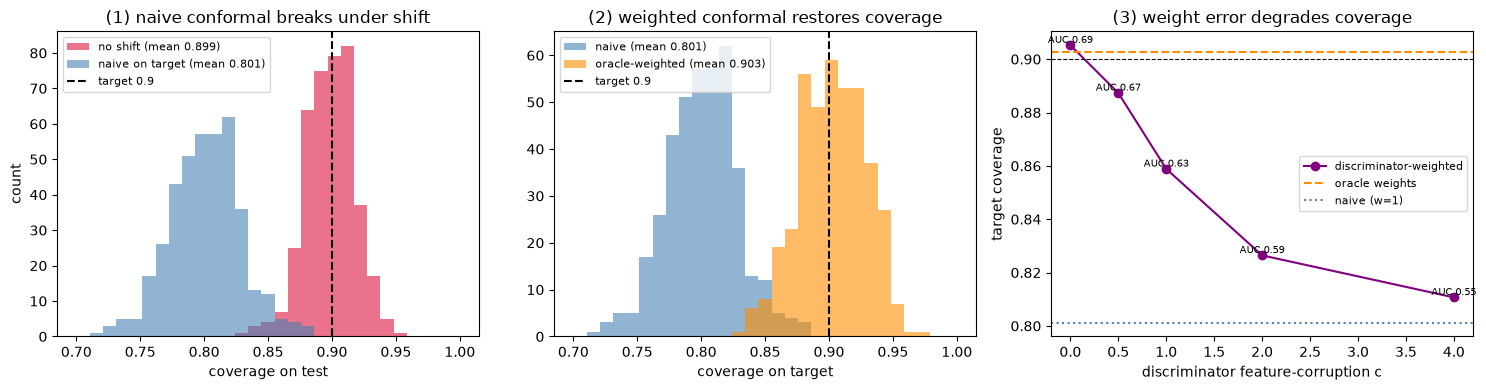

In [ ]:
# Three panels: (1) naive breaks, (2) weighted restores, (3) weight-error degrades
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
b = np.linspace(0.7, 1.0, 30)

ax[0].hist(cov_noshift, bins=b, alpha=0.6, color="crimson",   label=f"no shift (mean {cov_noshift.mean():.3f})")
ax[0].hist(cov_naive,   bins=b, alpha=0.6, color="steelblue", label=f"naive on target (mean {cov_naive.mean():.3f})")
ax[0].axvline(1 - ALPHA, color="black", ls="--", label=f"target {1 - ALPHA}")
ax[0].set_title("(1) naive conformal breaks under shift")
ax[0].set_xlabel("coverage on test"); ax[0].set_ylabel("count"); ax[0].legend(fontsize=8)

ax[1].hist(cov_naive,  bins=b, alpha=0.6, color="steelblue", label=f"naive (mean {cov_naive.mean():.3f})")
ax[1].hist(cov_oracle, bins=b, alpha=0.6, color="darkorange", label=f"oracle-weighted (mean {cov_oracle.mean():.3f})")
ax[1].axvline(1 - ALPHA, color="black", ls="--", label=f"target {1 - ALPHA}")
ax[1].set_title("(2) weighted conformal restores coverage")
ax[1].set_xlabel("coverage on target"); ax[1].legend(fontsize=8)

cov_means = [np.mean(disc_cov[c]) for c in CORRUPTS]
auc_means = [np.mean(disc_auc[c]) for c in CORRUPTS]
ax[2].plot(CORRUPTS, cov_means, "o-", color="purple", label="discriminator-weighted")
ax[2].axhline(cov_oracle.mean(), color="darkorange", ls="--", label="oracle weights")
ax[2].axhline(cov_naive.mean(),  color="steelblue",  ls=":",  label="naive (w=1)")
ax[2].axhline(1 - ALPHA, color="black", ls="--", lw=0.8)
for c, cov, a in zip(CORRUPTS, cov_means, auc_means):
    ax[2].annotate(f"AUC {a:.2f}", (c, cov), fontsize=7, ha="center", va="bottom")
ax[2].set_title("(3) weight error degrades coverage")
ax[2].set_xlabel("discriminator feature-corruption c"); ax[2].set_ylabel("target coverage")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Pitfall: importance-weight blow-up

Weighted conformal pays for the shift with **variance**. The relevant quantity is the *effective sample size* (Gretton et al. 2009; Tibshirani 2019, sec. 2.2)

    n_eff = (sum_i w_i)^2 / sum_i w_i^2 = ||w||_1^2 / ||w||_2^2,

equal to `n` when all weights match and collapsing toward `1` when one weight dominates. Because `w(x)=p_T/p_S` is **unbounded**, a stronger shift (or an over-confident discriminator with `d -> 1`) makes a few weights explode, `n_eff` crashes, and the finite-sample guarantee is effectively running on a handful of points -- the band gets wide and unstable even though the *expectation* stays correct. This is why the paper clips estimated weights (footnote 3), and why, downstream, an exploding `w(x)` is the **signal to abstain / route the point as OOD** rather than trust the weighted interval.

 tilt ETA   n_eff / 500  max w / mean w
      0.0         500.0             1.0
      0.5         390.3             4.0
      1.0         192.5            13.3
      1.5          75.8            35.7
      2.0          32.0            74.6
      3.0          10.2           158.3


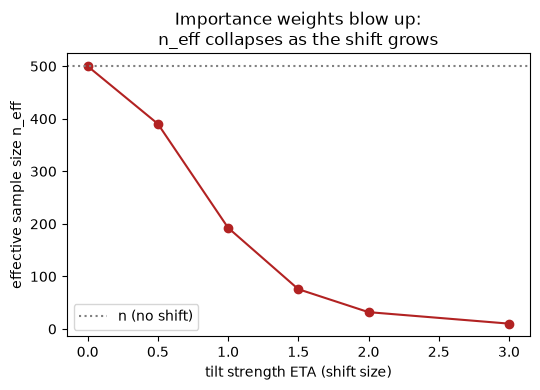

In [ ]:
rng = np.random.default_rng(3)
etas = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
ess_vals, ratio_vals = [], []
for eta in etas:                                     # average over draws for a clean curve
    es, rt = [], []
    for _ in range(300):
        w = np.exp(eta * rng.standard_normal(500))
        es.append(w.sum() ** 2 / (w ** 2).sum()); rt.append(w.max() / w.mean())
    ess_vals.append(np.mean(es)); ratio_vals.append(np.mean(rt))

print(f"{'tilt ETA':>9}{'n_eff / 500':>14}{'max w / mean w':>16}")
for eta, e, r in zip(etas, ess_vals, ratio_vals):
    print(f"{eta:>9.1f}{e:>14.1f}{r:>16.1f}")

plt.figure(figsize=(5.5, 4))
plt.plot(etas, ess_vals, "o-", color="firebrick")
plt.axhline(500, color="gray", ls=":", label="n (no shift)")
plt.xlabel("tilt strength ETA (shift size)"); plt.ylabel("effective sample size n_eff")
plt.title("Importance weights blow up:\nn_eff collapses as the shift grows")
plt.legend(); plt.tight_layout(); plt.show()

### (d) ACI: online coverage under drift (Gibbs & Candes 2021)

Weighted conformal needs a *target sample* and a *fixed* shift. The online setting is different: data arrive as a stream `(X_t, Y_t)`, the distribution drifts arbitrarily, and after predicting we **see the label** `Y_t`. ACI uses that feedback. With a working miscoverage level `alpha_t` (start `alpha_1 = alpha`), at each step:

1. form `C_t = { y : S_t(X_t, y) <= Q_t(1 - alpha_t) }` from the current score/quantile estimators;
2. observe `Y_t`, set `err_t = 1[Y_t not in C_t]`;
3. **update** (Gibbs & Candes eq. 2):  `alpha_{t+1} = alpha_t + gamma (alpha - err_t)`.

A miss (`err_t=1`) lowers `alpha_t` -> higher quantile -> wider next set; a run of hits raises it -> tighter sets. The boundaries are the safety valve: `alpha_t < 0` makes `Q_t(1-alpha_t)=Q_t(>1)=+inf` (set is everything, sure cover); `alpha_t > 1` makes it empty. Lemma 4.1 keeps `alpha_t in [-gamma, 1+gamma]`, and **Proposition 4.1** gives the long-run guarantee with *no* distributional assumptions:

    | (1/T) sum_t err_t - alpha |  <=  ( max(alpha_1, 1-alpha_1) + gamma ) / (T gamma)  ->  0.

`herbps10/AdaptiveConformal` implements this in `R/aci_algorithm.R`, parameterized by the coverage level `theta = 1 - alpha_t` (its `update_aci` does `theta += gamma*(err - (1-alpha))`, algebraically identical to eq. 2), with default `gamma = 0.01`, score `|Y - pred|`, and `type=1` empirical quantile. The cell below is the same algorithm in the paper's `alpha_t` form. **Both** methods compared use the *identical* trailing-window `Q_t` -- they differ only in whether `alpha_t` adapts, which isolates ACI's contribution. We also include the smoother weighted update (3).

In [ ]:
ALPHA_A, T, W, PRED, GAMMA = 0.10, 4000, 500, 100, 0.01
WARM = W + PRED                                       # need PRED for muhat, then W scores
rng = np.random.default_rng(7)

# Synthetic drifting stream: slow mean drift + a volatility burst (calm -> ramp
# up -> high plateau -> ramp down -> calm), mimicking a crisis regime.
N = T + WARM; t = np.arange(N)
mu_t = np.sin(2 * np.pi * t / 700.0)
ramp = np.clip((t - (WARM + 1200)) / 400.0, 0, 1)
down = np.clip(((WARM + 2600) - t) / 400.0, 0, 1)
sigma_t = 1.0 + 3.0 * np.minimum(ramp, down)         # noise scale 1 -> 4 -> 1
Y = mu_t + sigma_t * rng.standard_normal(N)

# online predictor = trailing mean (last PRED); nonconformity score |Y - muhat|
muhat = np.full(N, np.nan)
for i in range(PRED, N): muhat[i] = Y[i - PRED:i].mean()
abs_score = np.abs(Y - muhat)

def Q_window(scores, p):
    """Q_t(p) = inf{ s : Fhat(s) >= p } over the trailing window (paper eq. 1),
    with clamps Q(p>=1)=+inf (cover everything) and Q(p<=0)=-inf (empty). The
    +/-inf convention is what makes Lemma 4.1 / Prop 4.1 exact; herbps10 instead
    clamps the *level* to [0,1] (capping at the empirical max) -- a finite variant."""
    if p >= 1: return np.inf
    if p <= 0: return -np.inf
    s = np.sort(scores); n = len(s); k = int(np.ceil(p * n))
    return s[min(max(k, 1), n) - 1]

def run_stream(mode):
    """mode: 'fixed' (alpha_t == alpha), 'aci' (update 2), 'aci3' (weighted update 3)."""
    a = ALPHA_A; errs = np.zeros(T); alphas = np.zeros(T); is_inf = np.zeros(T, bool); hist = []
    for i in range(T):
        idx = WARM + i
        win = abs_score[idx - W:idx]                  # trailing window (all finite)
        a_use = ALPHA_A if mode == "fixed" else a
        q = Q_window(win, 1 - a_use)
        err = int(abs_score[idx] > q)                 # Y_t not in C_t  (q=inf -> err=0)
        errs[i] = err; alphas[i] = a_use; is_inf[i] = not np.isfinite(q); hist.append(err)
        if mode == "aci":                             # eq. (2)
            a = a + GAMMA * (ALPHA_A - err)
        elif mode == "aci3":                          # eq. (3): exp-weighted err history
            h = np.array(hist[::-1]); wd = 0.95 ** np.arange(len(h)); wd /= wd.sum()
            a = a + GAMMA * (ALPHA_A - (wd * h).sum())
    return errs, alphas, is_inf

err_fix, a_fix, _       = run_stream("fixed")
err_aci, a_aci, inf_aci = run_stream("aci")
err_ac3, a_ac3, _       = run_stream("aci3")

bound = (max(ALPHA_A, 1 - ALPHA_A) + GAMMA) / (T * GAMMA)
print(f"target coverage = {1 - ALPHA_A}")
print(f"  fixed alpha : long-run coverage = {1 - err_fix.mean():.4f}")
print(f"  ACI (eq. 2) : long-run coverage = {1 - err_aci.mean():.4f}   alpha_t in [{a_aci.min():.3f}, {a_aci.max():.3f}]")
print(f"  ACI (eq. 3) : long-run coverage = {1 - err_ac3.mean():.4f}   (smoother, ~identical)")
print(f"Prop 4.1 bound on |mean err - alpha| <= {bound:.4f};  ACI actual = {abs(err_aci.mean() - ALPHA_A):.4f}")
print(f"ACI hit the infinite-set valve (alpha_t < 0) {int(inf_aci.sum())} times during the burst")

target coverage = 0.9
  fixed alpha : long-run coverage = 0.8832
  ACI (eq. 2) : long-run coverage = 0.8982   alpha_t in [-0.008, 0.397]
  ACI (eq. 3) : long-run coverage = 0.8982   (smoother, ~identical)
Prop 4.1 bound on |mean err - alpha| <= 0.0227;  ACI actual = 0.0017
ACI hit the infinite-set valve (alpha_t < 0) 23 times during the burst


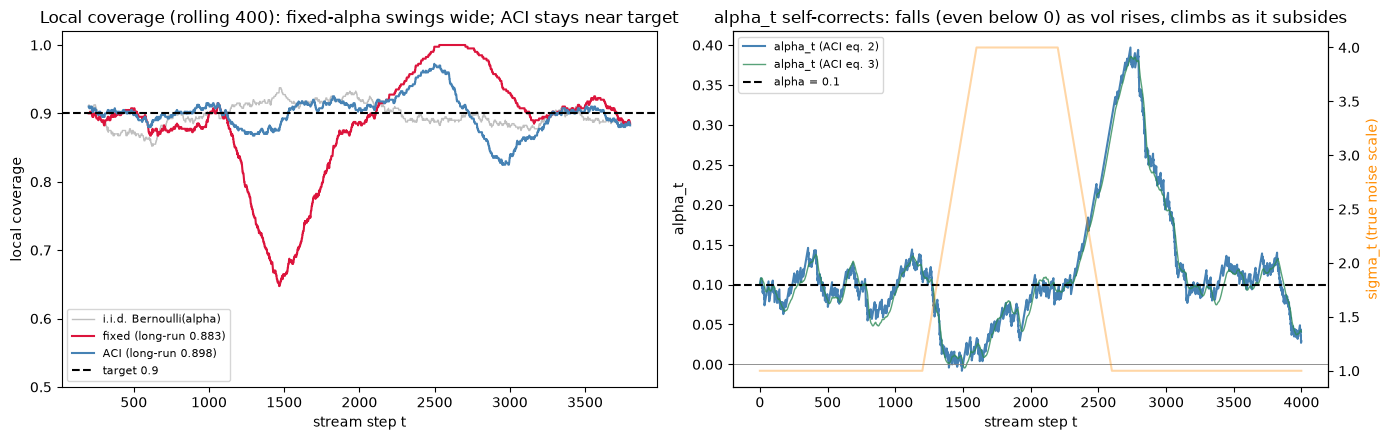

In [ ]:
def local_cov(errs, w=400): return np.convolve(1 - errs, np.ones(w) / w, mode="valid")
tt = np.arange(T)
lc_x = np.arange(len(local_cov(err_fix))) + 200                  # center the rolling window
berr = (rng.random(T) < ALPHA_A).astype(float)                  # i.i.d. Bernoulli(alpha) comparator

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].plot(lc_x, local_cov(berr),   color="gray",      alpha=0.5, lw=1, label="i.i.d. Bernoulli(alpha)")
ax[0].plot(lc_x, local_cov(err_fix), color="crimson",   label=f"fixed (long-run {1 - err_fix.mean():.3f})")
ax[0].plot(lc_x, local_cov(err_aci), color="steelblue", label=f"ACI (long-run {1 - err_aci.mean():.3f})")
ax[0].axhline(1 - ALPHA_A, color="black", ls="--", label=f"target {1 - ALPHA_A}")
ax[0].set_title("Local coverage (rolling 400): fixed-alpha swings wide; ACI stays near target")
ax[0].set_xlabel("stream step t"); ax[0].set_ylabel("local coverage"); ax[0].set_ylim(0.5, 1.02)
ax[0].legend(fontsize=8, loc="lower left")

ax[1].plot(tt, a_aci, color="steelblue", label="alpha_t (ACI eq. 2)")
ax[1].plot(tt, a_ac3, color="seagreen", lw=1, alpha=0.8, label="alpha_t (ACI eq. 3)")
ax[1].axhline(ALPHA_A, color="black", ls="--", label=f"alpha = {ALPHA_A}")
ax[1].axhline(0, color="gray", lw=0.6)
ax[1].set_xlabel("stream step t"); ax[1].set_ylabel("alpha_t"); ax[1].legend(fontsize=8, loc="upper left")
axb = ax[1].twinx()
axb.plot(tt, sigma_t[WARM:WARM + T], color="darkorange", alpha=0.35)
axb.set_ylabel("sigma_t (true noise scale)", color="darkorange")
ax[1].set_title("alpha_t self-corrects: falls (even below 0) as vol rises, climbs as it subsides")

plt.tight_layout(); plt.show()

### Done-when check

- **Weighted conformal = batch covariate shift with a target sample.** Fixed source, fixed target, `P(Y\|X)` unchanged, and you can sample (unlabeled) target covariates to estimate `w(x)=p_T/p_S`. Re-weighting calibration scores by `w` (eq. 7/10) gives **exact finite-sample** `1-alpha` on the target. Panels (1)-(2): naive falls to ~0.80, oracle weights return it to ~0.90. Panel (3): coverage degrades smoothly back toward naive as the discriminator's weights worsen (AUC -> 0.5).
- **ACI = online with label feedback, long-run guarantee.** No target sample, no known shift -- you see `Y_t` each step and adapt `alpha_t` by eq. (2). The promise is *long-run* empirical coverage -> `1-alpha` (Prop 4.1), with **no** assumption on the drift; it is **not** a per-step marginal guarantee. Fixed-`alpha` kept the right long-run average here too, but its **local** coverage swung wide -- a trough to ~0.65 as the burst hit, then an over-covering crest after it (the trailing window stays inflated by old large scores). ACI tracked target throughout: as volatility rose it **lowered** `alpha_t` (down past 0 -> the infinite-set valve) to widen, then **raised** `alpha_t` once the stale window began over-covering.
- **Complementary, not interchangeable.** Weighted conformal needs the ratio `w` and a static target; ACI needs label feedback and only controls the long run. Neither repairs the other's failure mode.
- **Pitfall carried forward:** unbounded `w` -> `n_eff` collapse -> unstable weighted intervals. That blow-up is the trigger for **OOD routing / abstention** (next steps), not something to weight through.
- **Recall from memory:** weighted threshold `q_hat(x) = Quantile(1-alpha; sum_i p_i(x) delta_{V_i} + p_{n+1}(x) delta_inf)` with `p_i(x) ∝ w(X_i)`; ACI update `alpha_{t+1} = alpha_t + gamma (alpha - err_t)`.

## Out-of-Distribution Detection + Distance-Aware Features

Weighted conformal (0.1.5) repairs *covariate shift* — but only while the target still **overlaps** the source. When a test point lands where the source has essentially no support, its importance weight `w(x) = p_T/p_S` explodes and the finite-sample guarantee dies (the ESS blow-up we flagged at the end of 0.1.5). The right move there is not to weight harder but to **abstain**: detect far-OOD inputs and route them out. This step builds that detector and shows *why feature geometry decides whether it works*.

Two post-hoc scores on the penultimate (pre-logit) features, each verified against the authors' code:

| | **Mahalanobis++** | **kNN** |
|---|---|---|
| repo | `mueller-mp/maha-norm` | `deeplearning-wisc/knn-ood` |
| paper | Lee et al. 2018 + Müller et al. 2025 (the "++") | Sun et al. 2022 |
| model of ID | parametric: class Gaussians, **one shared covariance** | non-parametric: the training features themselves |
| score | `-min_c (f-μ_c)ᵀ Σ⁻¹ (f-μ_c)` | `-(distance to the K-th nearest neighbor)` |
| first step | **L2-normalize the features** | **L2-normalize the features** |

The shared idea — and the maha-norm paper's central finding — is that the raw feature **norm** is an unreliable OOD signal: it varies wildly across models and breaks the Gaussian assumption behind the Mahalanobis distance. **L2-normalizing** removes that crutch and forces the score onto feature *direction / geometry*. That makes the detector only as good as the geometry — which is the whole point of part (b):

- **Feature collapse.** A network trained only to classify has no incentive to keep far-away inputs far in feature space; pushed to the terminal phase it can map them right onto the in-distribution feature manifold ("neural collapse", Papyan et al. 2020) — so far-OOD *looks* in-distribution.
- **Spectral normalization** (Miyato et al. 2018) bounds each layer's Lipschitz constant; with residual connections it becomes approximately **bi-Lipschitz** (Liu et al. 2020, SNGP) — it *preserves distances*, so far inputs stay far in feature space.

Plan: **(a)** implement both scores, compute AUROC vs a held-out far-OOD set; **(b)** retrain with spectral norm and watch the normalized-score AUROC jump; **(c)** connect it back to 0.1.5 — the far tail where `w(x)` blows up is exactly what OOD routing removes.

In [101]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt

# Self-contained OOD section. ID = 5 Gaussian classes in a D=20 feature space; only the first 3
# dims carry class signal, the other 17 are nuisance the classifier must learn to ignore.
# Held-out far-OOD = points on a large-radius shell (far from every class blob).
rng = np.random.default_rng(0); torch.manual_seed(0)
K, D, H, M_SIG = 5, 20, 32, 3
N_TR, N_TE, N_OOD = 2000, 1000, 1000
KN = 50                                   # kNN neighbor count (Sun 2022 use 50 at CIFAR scale)

centers = np.zeros((K, D)); centers[:, :M_SIG] = rng.standard_normal((K, M_SIG)) * 2.5
def sample_id(n):
    y = rng.integers(0, K, n)
    return (centers[y] + rng.standard_normal((n, D))).astype(np.float32), y
def _unit(v): return v / (np.linalg.norm(v, axis=-1, keepdims=True) + 1e-10)
def sample_ood(n, r=12.0):
    return (_unit(rng.standard_normal((n, D))) * r).astype(np.float32)

X_tr, y_tr = sample_id(N_TR); X_te, y_te = sample_id(N_TE); X_ood = sample_ood(N_OOD)

def _l2n(x): return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-10)

# Mahalanobis++  (mueller-mp/maha-norm, README reference impl). The "++" is the L2-norm.
# Class means + ONE shared covariance = EmpiricalCovariance(assume_centered=True) = Xc^T Xc / n;
# precision = pinv(cov); score = -min_c (f-mu_c)^T prec (f-mu_c). normalize=False = vanilla Lee 2018.
def maha_fit(F_tr, y, normalize):
    if normalize: F_tr = _l2n(F_tr)
    means = np.stack([F_tr[y == c].mean(0) for c in range(K)])
    Xc = np.concatenate([F_tr[y == c] - means[c] for c in range(K)])
    return means, np.linalg.pinv(Xc.T @ Xc / len(Xc)), normalize, Xc
def maha_score(F_, fit):
    means, prec, normalize, _ = fit
    if normalize: F_ = _l2n(F_)
    diff = F_[:, None, :] - means[None]                       # (n, K, D)
    return -np.einsum("nki,ij,nkj->nk", diff, prec, diff).min(1)   # higher = more in-distribution

# kNN OOD  (deeplearning-wisc/knn-ood, run_cifar.py). L2-normalize, squared-L2 to the K-th
# nearest training neighbor (faiss IndexFlatL2 returns sorted squared dists), score = -D[:,-1].
def knn_score(F_tr, F_, k=KN):
    a, b = _l2n(F_tr), _l2n(F_)
    d2 = (b**2).sum(1)[:, None] + (a**2).sum(1)[None] - 2 * b @ a.T
    d2.sort(1)
    return -d2[:, k - 1]

def auc_score(scr, lab):                  # rank-based AUROC, no sklearn (as in 0.1.5)
    order = np.argsort(scr); r = np.empty(len(scr)); r[order] = np.arange(1, len(scr) + 1)
    n1 = lab.sum(); n0 = len(lab) - n1
    return (r[lab == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

# --- cross-checks against the canonical conventions ---
_F = rng.standard_normal((300, D)).astype(np.float32); _y = rng.integers(0, K, 300)
_, _prec, _, _Xc = maha_fit(_F, _y, normalize=True)
# (i) shared covariance == EmpiricalCovariance(assume_centered=True): Xc^T Xc / n == np.cov(bias)
assert np.allclose(_Xc.T @ _Xc / len(_Xc), np.cov(_Xc, rowvar=False, bias=True), atol=1e-6)
# (ii) kNN K-th-NN squared distance == brute-force per-point loop
_Q = rng.standard_normal((5, D)).astype(np.float32); _a = _l2n(_F); _qn = _l2n(_Q)
_brute = np.array([np.sort(((_a - q) ** 2).sum(1))[KN - 1] for q in _qn])
assert np.allclose(-_brute, knn_score(_F, _Q)), "kNN K-th distance mismatch"
print("cross-checks passed: shared-cov == EmpiricalCovariance(assume_centered) formula; "
      "kNN == brute-force K-th NN")

cross-checks passed: shared-cov == EmpiricalCovariance(assume_centered) formula; kNN == brute-force K-th NN


### The backbone, three ways (with and without distance preservation)

Same MLP, three constraints. `vanilla` is the unconstrained classifier. `spectral-norm` wraps the two hidden layers in `spectral_norm` (caps the largest singular value → an **upper**-Lipschitz bound, so the map cannot stretch distances arbitrarily). `SN+residual` adds skip connections `h + f(h)`, which also **lower**-bound the Lipschitz constant — the approximately bi-Lipschitz recipe from SNGP (Liu et al. 2020) that keeps distinct inputs from collapsing together.

We train into the terminal phase (long, with weight decay) **on purpose**: that is exactly the regime where an unconstrained net collapses its features and far-OOD detection should suffer.

In [102]:
def SN(layer): return nn.utils.spectral_norm(layer)   # Miyato 2018: bound the top singular value

class Backbone(nn.Module):
    """sn=True spectral-normalizes the hidden maps (upper-Lipschitz bound). res=True adds skips
    h + f(h) so the map is also lower-Lipschitz -> approx bi-Lipschitz (Liu 2020 / SNGP)."""
    def __init__(self, sn, res):
        super().__init__(); self.res = res
        mk = (lambda a, b: SN(nn.Linear(a, b))) if sn else nn.Linear
        self.l1 = mk(D, H); self.l2 = mk(H, H); self.head = nn.Linear(H, K)
    def feat(self, x):
        h = F.relu(self.l1(x))
        h = h + F.relu(self.l2(h)) if self.res else F.relu(self.l2(h))
        return h
    def forward(self, x): return self.head(self.feat(x))

def train_backbone(sn, res, epochs=2000, wd=1e-3, seed=0):
    torch.manual_seed(seed); net = Backbone(sn, res)
    Xt, yt = torch.tensor(X_tr), torch.tensor(y_tr)
    opt = optim.Adam(net.parameters(), lr=1e-2, weight_decay=wd)   # train into the terminal phase
    for _ in range(epochs):
        opt.zero_grad(); F.cross_entropy(net(Xt), yt).backward(); opt.step()
    with torch.no_grad():
        acc  = (net(torch.tensor(X_te)).argmax(1).numpy() == y_te).mean()
        f_tr = net.feat(Xt).numpy()
        f_te = net.feat(torch.tensor(X_te)).numpy()
        f_oo = net.feat(torch.tensor(X_ood)).numpy()
    return dict(acc=acc, f_tr=f_tr, f_te=f_te, f_oo=f_oo)

BACK = {"vanilla":       train_backbone(sn=False, res=False),
        "spectral-norm": train_backbone(sn=True,  res=False),
        "SN+residual":   train_backbone(sn=True,  res=True)}
for n, b in BACK.items():
    print(f"{n:14s} test acc = {b['acc']:.3f}")

vanilla        test acc = 0.800
spectral-norm  test acc = 0.837
SN+residual    test acc = 0.821


### (a)+(b) AUROC: raw Mahalanobis hides the problem; the normalized scores expose it

Three scores per backbone: **raw Mahalanobis** (no normalization — Lee 2018), **Mahalanobis++** (L2-normalized — the improved version), and **kNN** (L2-normalized). `within-cls-var` is the mean within-class feature variance — a direct read on feature collapse / spread.

What to watch: **raw Maha looks near-perfect for every backbone**, because far-OOD here happens to land at large feature norm — but the maha-norm paper's whole point is that the norm is not a trustworthy signal. Once we L2-normalize (Maha++ / kNN), the score depends only on geometry, and the **vanilla** backbone is visibly worse than the spectral-norm ones. This *is* the playbook's pitfall: if you compute Mahalanobis on collapsed features and conclude "OOD detection doesn't work," the thing to fix is the **features**, not the method.

In [103]:
lab = np.concatenate([np.ones(N_TE), np.zeros(N_OOD)])     # 1 = ID, 0 = OOD
def within_var(f, y): return np.mean([f[y == c].var(0).sum() for c in range(K)])

results = {}
print(f"{'backbone':14s}{'Maha(raw)':>11s}{'Maha++':>9s}{'kNN':>8s}{'within-cls-var':>16s}")
for n, b in BACK.items():
    raw = auc_score(np.concatenate([maha_score(b['f_te'], maha_fit(b['f_tr'], y_tr, False)),
                                    maha_score(b['f_oo'], maha_fit(b['f_tr'], y_tr, False))]), lab)
    pp  = auc_score(np.concatenate([maha_score(b['f_te'], maha_fit(b['f_tr'], y_tr, True)),
                                    maha_score(b['f_oo'], maha_fit(b['f_tr'], y_tr, True))]), lab)
    knn = auc_score(np.concatenate([knn_score(b['f_tr'], b['f_te']), knn_score(b['f_tr'], b['f_oo'])]), lab)
    results[n] = dict(raw=raw, pp=pp, knn=knn, wv=within_var(b['f_tr'], y_tr))
    print(f"{n:14s}{raw:>11.3f}{pp:>9.3f}{knn:>8.3f}{results[n]['wv']:>16.2f}")
print("\nraw Maha ~1.0 everywhere -- it rides the feature NORM (unreliable; maha-norm Fig 1).")
print("after L2-norm: vanilla features are mediocre (collapse -> high within-class var);")
print("spectral norm restores separation (Maha++/kNN up, within-class var down ~10x).")

backbone        Maha(raw)   Maha++     kNN  within-cls-var
vanilla             0.996    0.927   0.895            8.60
spectral-norm       0.995    0.988   0.966            0.83
SN+residual         1.000    0.981   0.964            8.85

raw Maha ~1.0 everywhere -- it rides the feature NORM (unreliable; maha-norm Fig 1).
after L2-norm: vanilla features are mediocre (collapse -> high within-class var);
spectral norm restores separation (Maha++/kNN up, within-class var down ~10x).


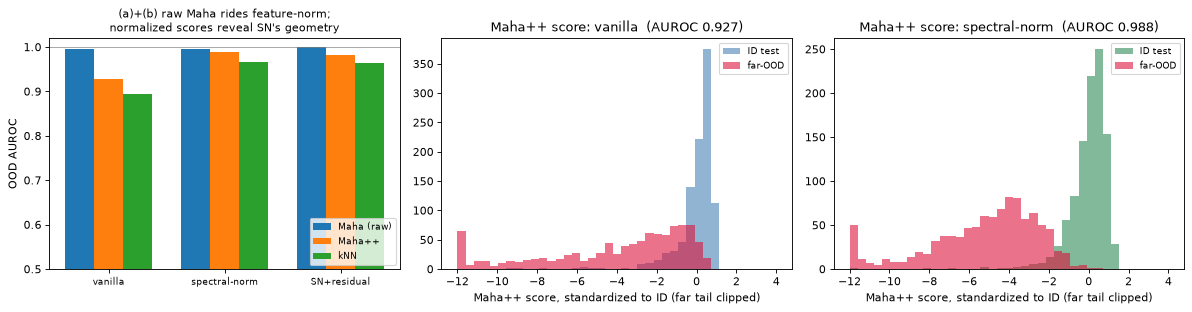

In [104]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
names = list(BACK); xpos = np.arange(len(names))
for i, key in enumerate(["raw", "pp", "knn"]):
    ax[0].bar(xpos + (i - 1) * 0.25, [results[n][key] for n in names], 0.25,
              label={"raw": "Maha (raw)", "pp": "Maha++", "knn": "kNN"}[key])
ax[0].set_xticks(xpos); ax[0].set_xticklabels(names, fontsize=8); ax[0].set_ylim(0.5, 1.02)
ax[0].axhline(1.0, color="gray", lw=0.6); ax[0].set_ylabel("OOD AUROC")
ax[0].set_title("(a)+(b) raw Maha rides feature-norm;\nnormalized scores reveal SN's geometry", fontsize=10)
ax[0].legend(fontsize=8, loc="lower right")

for axi, n, col in [(ax[1], "vanilla", "steelblue"), (ax[2], "spectral-norm", "seagreen")]:
    fit = maha_fit(BACK[n]["f_tr"], y_tr, True)
    s_id, s_oo = maha_score(BACK[n]["f_te"], fit), maha_score(BACK[n]["f_oo"], fit)
    mu, sd = s_id.mean(), s_id.std()                       # standardize to the ID cluster
    z_id, z_oo = (s_id - mu) / sd, (s_oo - mu) / sd
    bins = np.linspace(-12, 4, 40)
    axi.hist(np.clip(z_id, -12, 4), bins, alpha=0.6, color=col,      label="ID test")
    axi.hist(np.clip(z_oo, -12, 4), bins, alpha=0.6, color="crimson", label="far-OOD")
    axi.set_title(f"Maha++ score: {n}  (AUROC {results[n]['pp']:.3f})")
    axi.set_xlabel("Maha++ score, standardized to ID (far tail clipped)"); axi.legend(fontsize=8)
plt.tight_layout(); plt.show()

### (c) Why OOD routing rescues the weighted guarantee

Back to 0.1.5's importance weight `w(x) = p_T(x)/p_S(x)`. Make the target a mild covariate shift **plus** a 10% far-OOD component sitting in the source's deep tail. Two facts line up:

1. For a Gaussian source, the Mahalanobis OOD score `|x-μ_S|/σ_S` is **monotone in `-log p_S(x)`** — so the OOD score and the weight `w = p_T/p_S` blow up in the *same* far tail.
2. A handful of far-OOD points with astronomical weights destroy the **effective sample size** `n_eff = (Σ wᵢ)² / Σ wᵢ²`, and with it the finite-sample weighted-conformal bound.

So **thresholding the OOD score is the same operation as capping the importance weight.** Routing the far tail to abstain takes `n_eff` from "collapsed" back to "healthy" — which is what makes the weighted guarantee usable in the first place.

In [105]:
# Same importance weight w = p_T/p_S as 0.1.5, now with a far-OOD component in the target.
# Under a Gaussian source, the 1-D Mahalanobis OOD score |x-muS|/sigS is monotone in -log p_S(x),
# so w = p_T/p_S blows up EXACTLY where the OOD score is large. Routing the far tail to abstain
# is therefore precisely what caps w and rescues the effective sample size (the finite-sample
# weighted-conformal bound degrades as ESS shrinks -- Tibshirani 2019).
rng = np.random.default_rng(6)
muS, sdS = 0.0, 1.0
mu_shift, rho, mu_far = 1.0, 0.10, 6.0       # target = mild covariate shift + 10% far-OOD at x=6
def pdf(x, mu, sd): return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))
p_S = lambda x: pdf(x, muS, sdS)
p_T = lambda x: (1 - rho) * pdf(x, mu_shift, sdS) + rho * pdf(x, mu_far, sdS)

nT = 4000
comp = rng.random(nT) < rho
xT = np.where(comp, rng.normal(mu_far, sdS, nT), rng.normal(mu_shift, sdS, nT))
w   = p_T(xT) / p_S(xT)                       # oracle importance weight
ood = np.abs(xT - muS) / sdS                  # 1-D Mahalanobis OOD score
ess = lambda u: u.sum() ** 2 / (u ** 2).sum()

order = np.argsort(ood)[::-1]                 # route highest-OOD-score points first
fracs = np.linspace(0, 0.25, 80)
ess_by_frac  = np.array([ess(w[order[int(fr * nT):]])      for fr in fracs])
maxw_by_frac = np.array([w[order[int(fr * nT):]].max()     for fr in fracs])
keep = ood <= 3.5
print(f"target n={nT}: ESS with ALL weights = {ess(w):.1f}  (a 10% far-OOD tail collapses it)")
print(f"route the top ~{rho * 100:.0f}% by OOD score to abstain: "
      f"ESS {ess(w):.1f} -> {ess(w[keep]):.0f};  max weight {w.max():.0e} -> {w[keep].max():.1f}")

target n=4000: ESS with ALL weights = 2.1  (a 10% far-OOD tail collapses it)
route the top ~10% by OOD score to abstain: ESS 2.1 -> 1613;  max weight 3e+14 -> 19.9


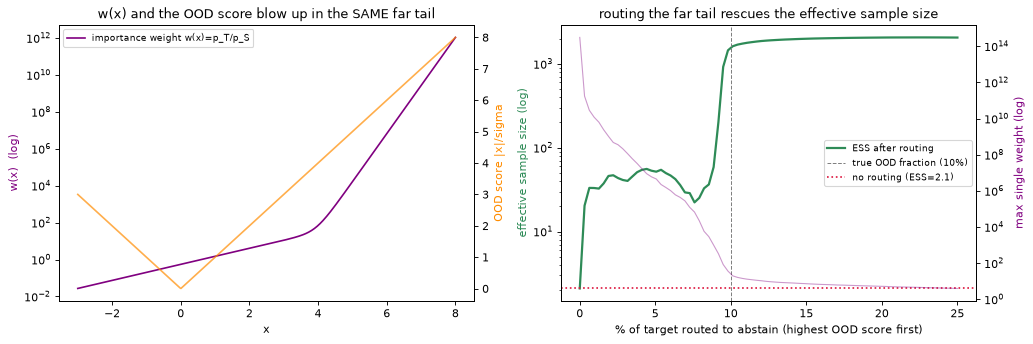

In [106]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
xg = np.linspace(-3, 8, 400)
ax[0].plot(xg, p_T(xg) / p_S(xg), color="purple", label="importance weight w(x)=p_T/p_S")
ax[0].set_yscale("log"); ax[0].set_xlabel("x"); ax[0].set_ylabel("w(x)  (log)", color="purple")
axt = ax[0].twinx(); axt.plot(xg, np.abs(xg - muS) / sdS, color="darkorange", alpha=0.7)
axt.set_ylabel("OOD score |x|/sigma", color="darkorange")
ax[0].legend(fontsize=8, loc="upper left")
ax[0].set_title("w(x) and the OOD score blow up in the SAME far tail")

ax[1].plot(fracs * 100, ess_by_frac, "-", color="seagreen", lw=2, label="ESS after routing")
ax[1].set_yscale("log"); ax[1].set_ylabel("effective sample size (log)", color="seagreen")
ax[1].axvline(rho * 100, color="gray", ls="--", lw=0.9, label=f"true OOD fraction ({rho * 100:.0f}%)")
ax[1].axhline(ess(w), color="crimson", ls=":", label=f"no routing (ESS={ess(w):.1f})")
axw = ax[1].twinx(); axw.plot(fracs * 100, maxw_by_frac, color="purple", alpha=0.4, lw=1)
axw.set_yscale("log"); axw.set_ylabel("max single weight (log)", color="purple")
ax[1].set_xlabel("% of target routed to abstain (highest OOD score first)")
ax[1].set_title("routing the far tail rescues the effective sample size")
ax[1].legend(fontsize=8, loc="center right")
plt.tight_layout(); plt.show()

### Done-when check

**Why "route far-OOD to abstain" both protects patients (4) and keeps the weighted guarantee usable (3):**

- **(4) Patient safety.** Far-OOD is the regime where the model extrapolates with no support — the prediction, and its conformal set, carry no real guarantee. Abstaining and escalating to a human is the safe action; emitting a confident interval there is exactly the failure mode we must avoid.
- **(3) A usable weighted guarantee.** Weighted conformal only repairs shift while `w(x)` stays bounded enough to keep `n_eff` large. Far-OOD points are precisely the ones with exploding `w`, so removing them is what keeps the finite-sample bound from going vacuous. Routing and weighting are **complementary**: routing handles the no-overlap tail; weighting handles the overlapping-but-shifted bulk.

**What the experiments showed (seed 0):**
- raw Mahalanobis AUROC ≈ 0.99–1.0 for *every* backbone — but that rides the feature **norm**, which the maha-norm paper shows is unreliable, not the geometry.
- with the norm removed, the **vanilla** backbone is mediocre (Maha++ ≈ 0.93, kNN ≈ 0.90) while **spectral norm** restores separation (Maha++ ≈ 0.99, kNN ≈ 0.97) and shrinks within-class variance ~10× — distance-aware features resist collapse. **Fix the features first.**
- a 10% far-OOD contamination collapsed the effective sample size from 4000 to ≈ 2 (max weight ~10¹⁴); routing the top ~10% by OOD score restored ESS to ≈ 1600 (max weight ≈ 20).

**Pitfall (carried forward):** the OOD score is only as good as the feature geometry — Mahalanobis on collapsed features looks broken when the method is fine. And note the honesty caveats: we used a *clean* held-out OOD set at a known radius; real far-OOD is messier, near-OOD is harder, and L2-norm + a single shared covariance are exactly that — assumptions.

*Next: fold OOD routing, selection, and weighting into one risk budget and show the three exchangeability-breaking operations compose (Phase 1 / 2.2).*